# Reverse correlation + LNP (synthetic demo)

**Goal**: recover a known stimulus filter using STA and a Poisson GLM fit.


In [1]:
# Reproducibility (required)
import numpy as np
import tneuro

rng = np.random.default_rng(7)
print("numpy", np.__version__)
print("tneuro", tneuro.__version__)


numpy 2.3.5
tneuro 0.1.0


**Model/derivation summary**: we generate a 1D stimulus, pass it through a
causal linear filter, apply an exponential nonlinearity, and sample Poisson
spike counts. We then recover the filter via the spike-triggered average (STA)
and via a Poisson GLM fit.


**Implementation**: (1) create a synthetic stimulus, (2) define a causal filter,
(3) simulate spikes with an LNP model, (4) compute STA, and (5) fit a Poisson GLM
using the same lags as the true filter.


In [2]:
import matplotlib.pyplot as plt
from tneuro.encoding.reverse_correlation import spike_triggered_average
from tneuro.encoding.glm_poisson import build_design_matrix, fit_poisson_glm

# Stimulus
fs_hz = 500.0
dt_s = 1.0 / fs_hz
t_s = 30.0
n = int(fs_hz * t_s)
t = np.arange(n) * dt_s
stim = rng.standard_normal(n)

# True causal filter (lags: -50..0 ms)
window_s = 0.05
n_lags = int(window_s * fs_hz) + 1
lags = np.arange(-n_lags + 1, 1, dtype=int)  # negative to zero
lags_s = lags * dt_s

# Exponential decay filter (normalized)
true_filter = np.exp(lags_s / 0.015)
true_filter /= np.linalg.norm(true_filter)

# Linear drive and rate
x_mat, valid_idx = build_design_matrix(stim, lags)
lin_drive = x_mat @ np.concatenate(([0.0], true_filter))
rate_hz = np.exp(-0.4 + 1.4 * lin_drive)
rate_hz = np.clip(rate_hz, 1e-3, 200.0)

# Sample Poisson counts per bin (align to full stimulus length)
spike_counts_valid = rng.poisson(rate_hz * dt_s)
spike_counts = np.zeros_like(stim, dtype=int)
spike_counts[valid_idx] = spike_counts_valid


**Results**: STA and GLM fit should resemble the true filter (up to scale).


corr(true, STA) 0.7914894631787794
corr(true, GLM) 0.7074677452219054
glm converged True in 12 iters


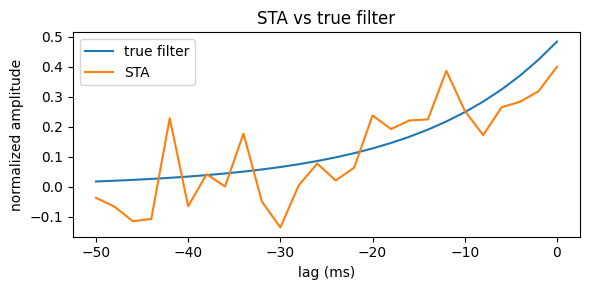

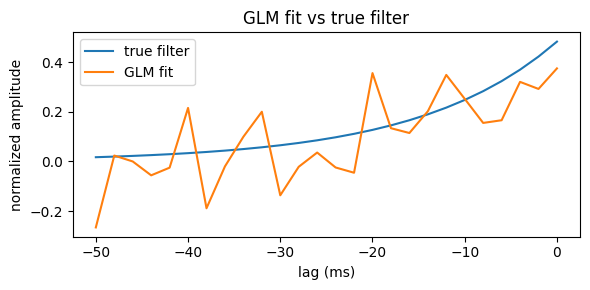

In [3]:
# Convert spike counts to spike times for STA
spike_times = []
for i, c in enumerate(spike_counts):
    if c > 0:
        # place spikes uniformly within the bin
        spike_times.extend(t[i] + rng.random(c) * dt_s)
spike_times = np.asarray(spike_times, dtype=float)

sta, sta_lags = spike_triggered_average(
    stim=stim,
    spike_times=spike_times,
    fs_hz=fs_hz,
    window_s=(0.05, 0.0),
)

# Normalize for shape comparison
sta_norm = sta / np.linalg.norm(sta)
true_norm = true_filter / np.linalg.norm(true_filter)

plt.figure(figsize=(6, 3))
plt.plot(lags_s * 1000.0, true_norm, label="true filter")
plt.plot(sta_lags * 1000.0, sta_norm, label="STA")
plt.xlabel("lag (ms)")
plt.ylabel("normalized amplitude")
plt.title("STA vs true filter")
plt.legend()
plt.tight_layout()

# Fit Poisson GLM
result = fit_poisson_glm(stim, spike_counts, lags)
coef = result.coef
coef_filter = coef[1:]  # drop intercept
coef_norm = coef_filter / np.linalg.norm(coef_filter)

plt.figure(figsize=(6, 3))
plt.plot(lags_s * 1000.0, true_norm, label="true filter")
plt.plot(lags_s * 1000.0, coef_norm, label="GLM fit")
plt.xlabel("lag (ms)")
plt.ylabel("normalized amplitude")
plt.title("GLM fit vs true filter")
plt.legend()
plt.tight_layout()

# Numeric checks
corr_sta = float(np.corrcoef(true_norm, sta_norm)[0, 1])
corr_glm = float(np.corrcoef(true_norm, coef_norm)[0, 1])
print("corr(true, STA)", corr_sta)
print("corr(true, GLM)", corr_glm)
print("glm converged", result.converged, "in", result.n_iter, "iters")


**Sanity checks**: correlations should be positive and GLM should converge.


In [4]:
if corr_sta <= 0.0:
    raise ValueError("STA correlation should be positive.")
if corr_glm <= 0.0:
    raise ValueError("GLM correlation should be positive.")
if not result.converged:
    raise RuntimeError("GLM did not converge.")
